In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [2]:
import pandas as pd

df = pd.read_csv("logon.csv")
print(df.head())
print(df.columns)
print(df.shape)

                         id                 date     user       pc activity
0  {F3X8-Y2GT43DR-4906OHBL}  01/02/2010 02:19:18  DNS1758  PC-0414    Logon
1  {B4Q0-D0GM24KN-3704MAII}  01/02/2010 02:31:12  DNS1758  PC-0414   Logoff
2  {T7J1-D4HK34KV-5476TCIJ}  01/02/2010 02:34:02  DNS1758  PC-5313    Logon
3  {S4Y6-D8MQ05SA-0759HLIS}  01/02/2010 02:53:30  DNS1758  PC-5313   Logoff
4  {F3P0-E7FH78CV-4874FRGZ}  01/02/2010 04:07:31  DNS1758  PC-0012    Logon
Index(['id', 'date', 'user', 'pc', 'activity'], dtype='object')
(153201, 5)


### Print columns and unique values:

In [3]:
print(df.columns.tolist())
print(df["activity"].unique())   # adjust if activity column has another name

['id', 'date', 'user', 'pc', 'activity']
['Logon' 'Logoff' nan]


### Inspect Nulls


In [4]:
print(df.isnull().sum())

id          0
date        0
user        1
pc          1
activity    1
dtype: int64


### Convert timestamp into a datetime format

In [8]:
df["date"] = pd.to_datetime(df["date"], errors='coerce')

In [9]:
df["day"] = df["date"].dt.date
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.weekday

### Define working-hour boundaries
Define working-hour boundaries

In [18]:
print("Starting Step 4")

# Remove rows where activity is missing
df = df.dropna(subset=["activity"]).copy()

# Make sure numeric columns are integers
df["hour"] = df["hour"].astype(int)
df["weekday"] = df["weekday"].astype(int)
df["after_hours"] = df["after_hours"].astype(int)
df["weekend"] = df["weekend"].astype(int)
df["is_logon"] = df["is_logon"].astype(int)
df["is_logoff"] = df["is_logoff"].astype(int)

print("Step 4 complete")
print(df[["date", "user", "pc", "activity", "day", "hour", "weekday", "after_hours", "weekend", "is_logon", "is_logoff"]].head())
print("Shape after cleaning:", df.shape)

Starting Step 4
Step 4 complete
                 date     user       pc activity         day  hour  weekday  \
0 2010-01-02 02:19:18  DNS1758  PC-0414    Logon  2010-01-02     2        5   
1 2010-01-02 02:31:12  DNS1758  PC-0414   Logoff  2010-01-02     2        5   
2 2010-01-02 02:34:02  DNS1758  PC-5313    Logon  2010-01-02     2        5   
3 2010-01-02 02:53:30  DNS1758  PC-5313   Logoff  2010-01-02     2        5   
4 2010-01-02 04:07:31  DNS1758  PC-0012    Logon  2010-01-02     4        5   

   after_hours  weekend  is_logon  is_logoff  
0            1        1         1          0  
1            1        1         0          1  
2            1        1         1          0  
3            1        1         0          1  
4            1        1         1          0  
Shape after cleaning: (153200, 12)


### Create user-day behavioural features

Aggregate raw event rows into one behavioural row per user per day.


Autoencoders require fixed-size input vectors.
Raw logs are variable-length.
This step converts them into a tabular format.

Assume:
user = user column
pc = machine column
activity = activity type

In [19]:
print("Starting Step 5")

features = df.groupby(["user", "day"], as_index=False).agg(
    total_events=("activity", "count"),
    logon_count=("is_logon", "sum"),
    logoff_count=("is_logoff", "sum"),
    unique_hosts=("pc", "nunique"),
    first_login_hour=("hour", "min"),
    last_activity_hour=("hour", "max"),
    after_hours_count=("after_hours", "sum"),
    weekend_flag=("weekend", "max"),
    hour_std=("hour", "std")
)

# Fill NaN from std when only one event exists
features["hour_std"] = features["hour_std"].fillna(0)

# Add ratio features
features["after_hours_ratio"] = features["after_hours_count"] / features["total_events"]
features["logon_logoff_ratio"] = features["logon_count"] / (features["logoff_count"] + 1)

print("Step 5 complete")
print(features.head())
print("Feature table shape:", features.shape)

Starting Step 5
Step 5 complete
      user         day  total_events  logon_count  logoff_count  unique_hosts  \
0  AAB0162  2010-01-04             2            1             1             1   
1  AAB0162  2010-01-05             2            1             1             1   
2  AAB0162  2010-01-06             2            1             1             1   
3  AAB0162  2010-01-07             2            1             1             1   
4  AAB0162  2010-01-08             2            1             1             1   

   first_login_hour  last_activity_hour  after_hours_count  weekend_flag  \
0                 7                  18                  1             0   
1                 7                  18                  1             0   
2                 7                  18                  1             0   
3                 7                  18                  1             0   
4                 7                  18                  1             0   

   hour_std  after_hours

In [13]:
print(df.columns.tolist())
print(df.head(5))

['id', 'date', 'user', 'pc', 'activity', 'day', 'hour', 'weekday', 'after_hours', 'weekend']
                         id                date     user       pc activity  \
0  {F3X8-Y2GT43DR-4906OHBL} 2010-01-02 02:19:18  DNS1758  PC-0414    Logon   
1  {B4Q0-D0GM24KN-3704MAII} 2010-01-02 02:31:12  DNS1758  PC-0414   Logoff   
2  {T7J1-D4HK34KV-5476TCIJ} 2010-01-02 02:34:02  DNS1758  PC-5313    Logon   
3  {S4Y6-D8MQ05SA-0759HLIS} 2010-01-02 02:53:30  DNS1758  PC-5313   Logoff   
4  {F3P0-E7FH78CV-4874FRGZ} 2010-01-02 04:07:31  DNS1758  PC-0012    Logon   

          day  hour  weekday  after_hours  weekend  
0  2010-01-02   2.0      5.0            1        1  
1  2010-01-02   2.0      5.0            1        1  
2  2010-01-02   2.0      5.0            1        1  
3  2010-01-02   2.0      5.0            1        1  
4  2010-01-02   4.0      5.0            1        1  


In [14]:
print(df.columns.tolist())
print(df.head(5))

['id', 'date', 'user', 'pc', 'activity', 'day', 'hour', 'weekday', 'after_hours', 'weekend']
                         id                date     user       pc activity  \
0  {F3X8-Y2GT43DR-4906OHBL} 2010-01-02 02:19:18  DNS1758  PC-0414    Logon   
1  {B4Q0-D0GM24KN-3704MAII} 2010-01-02 02:31:12  DNS1758  PC-0414   Logoff   
2  {T7J1-D4HK34KV-5476TCIJ} 2010-01-02 02:34:02  DNS1758  PC-5313    Logon   
3  {S4Y6-D8MQ05SA-0759HLIS} 2010-01-02 02:53:30  DNS1758  PC-5313   Logoff   
4  {F3P0-E7FH78CV-4874FRGZ} 2010-01-02 04:07:31  DNS1758  PC-0012    Logon   

          day  hour  weekday  after_hours  weekend  
0  2010-01-02   2.0      5.0            1        1  
1  2010-01-02   2.0      5.0            1        1  
2  2010-01-02   2.0      5.0            1        1  
3  2010-01-02   2.0      5.0            1        1  
4  2010-01-02   4.0      5.0            1        1  


In [17]:
print(df.columns.tolist())
print(df.head(5))
print(df["activity"].value_counts(dropna=False).head(10))

['id', 'date', 'user', 'pc', 'activity', 'day', 'hour', 'weekday', 'after_hours', 'weekend', 'is_logon', 'is_logoff']
                         id                date     user       pc activity  \
0  {F3X8-Y2GT43DR-4906OHBL} 2010-01-02 02:19:18  DNS1758  PC-0414    Logon   
1  {B4Q0-D0GM24KN-3704MAII} 2010-01-02 02:31:12  DNS1758  PC-0414   Logoff   
2  {T7J1-D4HK34KV-5476TCIJ} 2010-01-02 02:34:02  DNS1758  PC-5313    Logon   
3  {S4Y6-D8MQ05SA-0759HLIS} 2010-01-02 02:53:30  DNS1758  PC-5313   Logoff   
4  {F3P0-E7FH78CV-4874FRGZ} 2010-01-02 04:07:31  DNS1758  PC-0012    Logon   

          day  hour  weekday  after_hours  weekend  is_logon  is_logoff  
0  2010-01-02   2.0      5.0            1        1         1          0  
1  2010-01-02   2.0      5.0            1        1         0          1  
2  2010-01-02   2.0      5.0            1        1         1          0  
3  2010-01-02   2.0      5.0            1        1         0          1  
4  2010-01-02   4.0      5.0            1  

In [21]:

feature_cols = [
    "total_events",
    "logon_count",
    "logoff_count",
    "unique_hosts",
    "first_login_hour",
    "last_activity_hour",
    "after_hours_count",
    "weekend_flag",
    "hour_std",
    "after_hours_ratio",
    "logon_logoff_ratio"
]

X = features[feature_cols].copy()
print(X.head())
print(X.shape)

   total_events  logon_count  logoff_count  unique_hosts  first_login_hour  \
0             2            1             1             1                 7   
1             2            1             1             1                 7   
2             2            1             1             1                 7   
3             2            1             1             1                 7   
4             2            1             1             1                 7   

   last_activity_hour  after_hours_count  weekend_flag  hour_std  \
0                  18                  1             0  7.778175   
1                  18                  1             0  7.778175   
2                  18                  1             0  7.778175   
3                  18                  1             0  7.778175   
4                  18                  1             0  7.778175   

   after_hours_ratio  logon_logoff_ratio  
0                0.5                 0.5  
1                0.5                

### Prepare input for the autoencoder

In [22]:
feature_cols = [
    "total_events",
    "logon_count",
    "logoff_count",
    "unique_hosts",
    "first_login_hour",
    "last_activity_hour",
    "after_hours_count",
    "weekend_flag",
    "hour_std",
    "after_hours_ratio",
    "logon_logoff_ratio"
]

X = features[feature_cols].copy()

print(X.head())
print(X.shape)

   total_events  logon_count  logoff_count  unique_hosts  first_login_hour  \
0             2            1             1             1                 7   
1             2            1             1             1                 7   
2             2            1             1             1                 7   
3             2            1             1             1                 7   
4             2            1             1             1                 7   

   last_activity_hour  after_hours_count  weekend_flag  hour_std  \
0                  18                  1             0  7.778175   
1                  18                  1             0  7.778175   
2                  18                  1             0  7.778175   
3                  18                  1             0  7.778175   
4                  18                  1             0  7.778175   

   after_hours_ratio  logon_logoff_ratio  
0                0.5                 0.5  
1                0.5                

### Scale the feature

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (61198, 11)


### Train/Test split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (48958, 11)
Test shape: (12240, 11)


### Build the autoencoder

In [25]:

import torch
import torch.nn as nn

input_dim = X_train.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = Autoencoder(input_dim)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=11, bias=True)
  )
)


### Convert to tensors

In [26]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

###Prepare input for the autoencoder

In [27]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, X_train_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 1.030139
Epoch 10, Loss: 1.010046
Epoch 20, Loss: 0.985181
Epoch 30, Loss: 0.940101
Epoch 40, Loss: 0.848814


### Compute anomaly scores

In [28]:
model.eval()

with torch.no_grad():
    reconstructed = model(X_test_tensor)
    mse = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1)

anomaly_scores = mse.numpy()

print("Sample anomaly scores:")
print(anomaly_scores[:10])

Sample anomaly scores:
[0.27172205 0.27172205 4.5342507  0.34854543 0.16473496 0.49333003
 1.0870763  0.3095199  0.36139363 0.16473496]


### Define threshold

In [29]:
with torch.no_grad():
    train_recon = model(X_train_tensor)
    train_mse = torch.mean((X_train_tensor - train_recon) ** 2, dim=1).numpy()

threshold = train_mse.mean() + 2 * train_mse.std()

print("Threshold:", threshold)

Threshold: 3.4309273


### Label anomalies

In [30]:

anomaly_labels = (anomaly_scores > threshold).astype(int)

print("Number of anomalies:", anomaly_labels.sum())

Number of anomalies: 643


### Map back to user-day

In [31]:
_, X_test_idx = train_test_split(features.index, test_size=0.2, random_state=42)

results = features.loc[X_test_idx, ["user", "day"]].copy()
results["anomaly_score"] = anomaly_scores
results["anomaly_label"] = anomaly_labels

results = results.sort_values("anomaly_score", ascending=False)

print(results.head(10))

          user         day  anomaly_score  anomaly_label
18881  EPI3052  2010-01-19      18.355675              1
19224  EUC1051  2010-01-15      16.800848              1
23300  HBB1759  2010-01-12      16.472013              1
35553  LCS3042  2010-01-22      14.575555              1
53960  TAM3048  2010-01-14      14.350012              1
58774  WOV3040  2010-01-20      14.331124              1
26371  IKP1047  2010-01-12      14.004760              1
30381  JPS2432  2010-01-19      13.861322              1
9911   CCB3055  2010-01-18      13.794127              1
9313   CAM3050  2010-01-12      13.746363              1


### Loss Plot

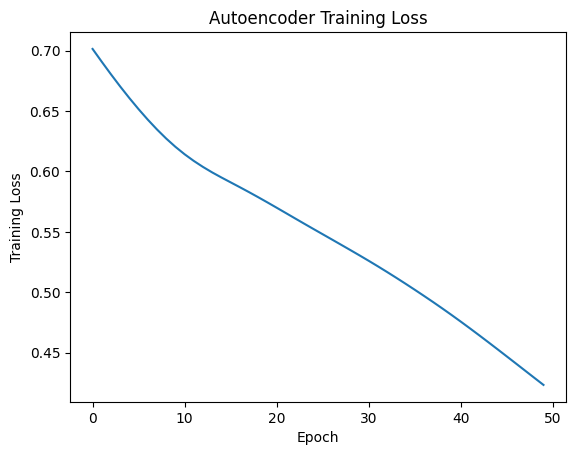

In [32]:
losses = []

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, X_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Autoencoder Training Loss")
plt.show()

### Anomaly Score Histogram

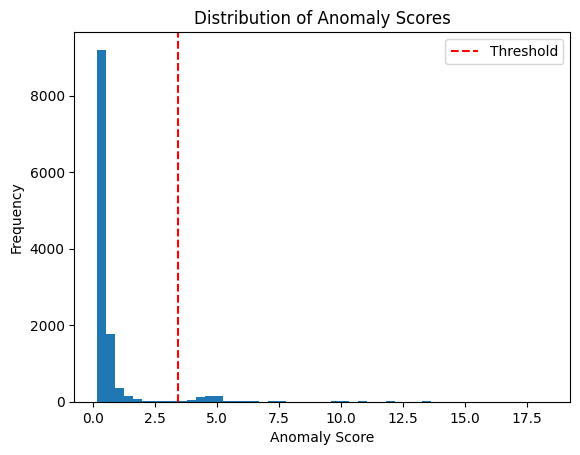

In [33]:
import matplotlib.pyplot as plt

plt.hist(anomaly_scores, bins=50)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.show()

### Extract feature-level anomaly contribution

In [34]:
reconstruction_error = (X_test_tensor - reconstructed) ** 2

error_df = pd.DataFrame(
    reconstruction_error.numpy(),
    columns=feature_cols,
    index=X_test_idx
)

### Identify top contributing features

In [35]:
def get_top_features(idx, n=3):
    return error_df.loc[idx].sort_values(ascending=False).head(n).index.tolist()

In [36]:
results["top_features"] = results.index.map(lambda i: get_top_features(i))

## Build psychology mapping rules
### Rule-based mapping

In [53]:
# -----------------------------
# STEP 1: Merge anomaly results with behavioural features
# -----------------------------
# This ensures anomaly scores and engineered features are in the same dataframe

results = results.merge(
    features,
    left_index=True,
    right_index=True,
    how="left"
)

print("Merged results shape:", results.shape)
print(results.head())


# -----------------------------
# STEP 2: Define psychology-informed mapping function
# -----------------------------
# This function maps anomaly + behavioural patterns to interpretive constructs

def map_psychology(row, threshold):
    constructs = []

    # 1. Boundary Crossing
    # User operates outside their normal behavioural boundary
    if row["after_hours_ratio"] > 0.5 or row["unique_hosts"] > 3:
        constructs.append("Boundary Crossing")

    # 2. Behavioural Volatility
    # High inconsistency in timing behaviour
    if row["hour_std"] > 3:
        constructs.append("Behavioural Volatility")

    # 3. Impulsive Spike
    # Very high anomaly score relative to threshold
    if row["anomaly_score"] > threshold * 1.5:
        constructs.append("Impulsive Spike")

    # Default label if no specific pattern matched
    if len(constructs) == 0:
        return "General Anomaly"

    return ", ".join(constructs)


# -----------------------------
# STEP 3: Apply the mapping function row-wise
# -----------------------------
results["psychology_label"] = results.apply(
    lambda row: map_psychology(row, threshold),
    axis=1
)

print("Psychology mapping added")
print(results[["user", "day", "anomaly_score", "psychology_label"]].head(10))


# -----------------------------
# STEP 4: Add Persistence
# -----------------------------
# If a user appears as anomalous multiple times, label as Persistence

# Count number of anomalous days per user
anomalous_users = results[results["anomaly_label"] == 1]["user"].value_counts()

# Define persistence threshold
# You can change >=3 to >=2 if you want a more sensitive rule
persistent_users = anomalous_users[anomalous_users >= 3].index

# Add Persistence label
def add_persistence(row):
    label = row["psychology_label"]
    if row["user"] in persistent_users:
        if "Persistence" not in label:
            label = label + ", Persistence"
    return label

results["psychology_label"] = results.apply(add_persistence, axis=1)


# -----------------------------
# STEP 5: Add top contributing features
# -----------------------------
# This shows which features contributed most to the anomaly

# Reconstruction error per feature
reconstruction_error = (X_test_tensor - reconstructed) ** 2

error_df = pd.DataFrame(
    reconstruction_error.numpy(),
    columns=feature_cols,
    index=X_test_idx
)

# Function to get top 3 features with highest reconstruction error
def get_top_features(idx, n=3):
    return error_df.loc[idx].sort_values(ascending=False).head(n).index.tolist()

results["top_features"] = results.index.map(lambda idx: get_top_features(idx, n=3))


# -----------------------------
# STEP 6: Final output table
# -----------------------------
final_results = results[[
    "user",
    "day",
    "anomaly_score",
    "anomaly_label",
    "psychology_label",
    "top_features"
]].sort_values("anomaly_score", ascending=False)

print("Final psychology-informed anomaly output:")
print(final_results.head(15))

Merged results shape: (12240, 35)
        user_x       day_x  anomaly_score  anomaly_label  \
18881  EPI3052  2010-01-19      18.355675              1   
19224  EUC1051  2010-01-15      16.800848              1   
23300  HBB1759  2010-01-12      16.472013              1   
35553  LCS3042  2010-01-22      14.575555              1   
53960  TAM3048  2010-01-14      14.350012              1   

                                            top_features  after_hours_ratio_x  \
18881     [after_hours_count, logoff_count, logon_count]             0.928571   
19224          [logon_count, logoff_count, total_events]             0.666667   
23300     [logon_count, logoff_count, after_hours_count]             0.666667   
35553  [last_activity_hour, after_hours_count, first_...             1.000000   
53960     [after_hours_count, logoff_count, logon_count]             0.916667   

       unique_hosts_x   psychology_label  hour_std_x   user_y  ...  \
18881               6  Boundary Crossing    8.27

### Clean Merge properly

In [61]:
results_clean = features.loc[X_test_idx].copy()
results_clean["anomaly_score"] = anomaly_scores
results_clean["anomaly_label"] = anomaly_labels

results_clean = results_clean[[
    "user",
    "day",
    "anomaly_score",
    "anomaly_label",
    "total_events",
    "logon_count",
    "logoff_count",
    "unique_hosts",
    "first_login_hour",
    "last_activity_hour",
    "after_hours_count",
    "weekend_flag",
    "hour_std",
    "after_hours_ratio",
    "logon_logoff_ratio"
]]

print(results_clean.head())
print(results_clean.shape)

          user         day  anomaly_score  anomaly_label  total_events  \
50544  SCB1280  2010-01-11       0.271722              0             2   
49527  RSA2941  2010-01-11       0.271722              0             2   
49887  RVB0303  2010-01-22       4.534251              1             2   
13667  CTC0421  2010-01-20       0.348545              0             3   
57778  WAW0422  2010-01-12       0.164735              0             2   

       logon_count  logoff_count  unique_hosts  first_login_hour  \
50544            1             1             1                 8   
49527            1             1             1                 8   
49887            2             0             1                 8   
13667            2             1             1                 7   
57778            1             1             1                 7   

       last_activity_hour  after_hours_count  weekend_flag  hour_std  \
50544                  17                  0             0  6.363961   
49

### Add top contributing features cleanly

In [67]:
reconstruction_error = (X_test_tensor - reconstructed) ** 2

error_df = pd.DataFrame(
    reconstruction_error.numpy(),
    columns=feature_cols,
    index=X_test_idx
)

results_clean["top_features"] = results_clean.index.map(
    lambda idx: error_df.loc[idx].sort_values(ascending=False).head(3).index.tolist()
)


### Improved psychology mapping rules

In [57]:
def map_psychology_v2(row, threshold):
    primary_label = None
    secondary_labels = []

    # Rule 1: Impulsive Spike
    # Very strong anomaly + unusually high event volume
    if row["anomaly_score"] > threshold * 2.5 and row["total_events"] >= 6:
        primary_label = "Impulsive Spike"

    # Rule 2: Boundary Crossing
    # High after-hours behaviour or unusually broad host access
    elif row["after_hours_ratio"] >= 0.7 or row["unique_hosts"] >= 5:
        primary_label = "Boundary Crossing"

    # Rule 3: Behavioural Volatility
    # High instability in activity timing
    elif row["hour_std"] >= 5:
        primary_label = "Behavioural Volatility"

    # Default
    else:
        primary_label = "General Anomaly"

    # Optional secondary labels
    if row["after_hours_ratio"] >= 0.85 and primary_label != "Boundary Crossing":
        secondary_labels.append("Boundary Crossing")

    if row["hour_std"] >= 6 and primary_label != "Behavioural Volatility":
        secondary_labels.append("Behavioural Volatility")

    if row["anomaly_score"] > threshold * 3 and primary_label != "Impulsive Spike":
        secondary_labels.append("Severe Deviation")

    if len(secondary_labels) > 0:
        return primary_label + " | " + ", ".join(secondary_labels)

    return primary_label

### Apply the improved mapping

In [64]:
results_clean["psychology_label"] = results_clean.apply(
    lambda row: map_psychology_v2(row, threshold),
    axis=1
)

print(results_clean[["user", "day", "anomaly_score", "psychology_label"]].head(15))

          user         day  anomaly_score        psychology_label
50544  SCB1280  2010-01-11       0.271722  Behavioural Volatility
49527  RSA2941  2010-01-11       0.271722  Behavioural Volatility
49887  RVB0303  2010-01-22       4.534251         General Anomaly
13667  CTC0421  2010-01-20       0.348545         General Anomaly
57778  WAW0422  2010-01-12       0.164735  Behavioural Volatility
17089  DSA3620  2010-01-05       0.493330         General Anomaly
15759  DJA0740  2010-01-19       1.087076         General Anomaly
3715   ANM0564  2010-01-06       0.309520  Behavioural Volatility
14499  DAM2954  2010-01-11       0.361394  Behavioural Volatility
43938  NUK1513  2010-01-13       0.164735  Behavioural Volatility
13609  CST2863  2010-01-22       0.192748  Behavioural Volatility
53022  SRM3245  2010-01-22       4.673781         General Anomaly
36543  LMB3241  2010-01-22       5.176836       Boundary Crossing
39246  MHB0845  2010-01-12       0.758836  Behavioural Volatility
60484  ZAW

### Adding persistence separately

In [65]:
anomalous_users = results_clean[results_clean["anomaly_label"] == 1]["user"].value_counts()

persistent_users = anomalous_users[anomalous_users >= 3].index

def add_persistence_v2(row):
    label = row["psychology_label"]
    if row["user"] in persistent_users:
        if "Persistence" not in label:
            label = label + " | Persistence"
    return label

results_clean["psychology_label"] = results_clean.apply(add_persistence_v2, axis=1)

### Final output table

In [66]:
final_results = results_clean[[
    "user",
    "day",
    "anomaly_score",
    "anomaly_label",
    "psychology_label",
    "top_features",
    "total_events",
    "unique_hosts",
    "after_hours_ratio",
    "hour_std"
]].sort_values("anomaly_score", ascending=False)

print(final_results.head(15))

          user         day  anomaly_score  anomaly_label  \
18881  EPI3052  2010-01-19      18.355675              1   
19224  EUC1051  2010-01-15      16.800848              1   
23300  HBB1759  2010-01-12      16.472013              1   
35553  LCS3042  2010-01-22      14.575555              1   
53960  TAM3048  2010-01-14      14.350012              1   
58774  WOV3040  2010-01-20      14.331124              1   
26371  IKP1047  2010-01-12      14.004760              1   
30381  JPS2432  2010-01-19      13.861322              1   
9911   CCB3055  2010-01-18      13.794127              1   
9313   CAM3050  2010-01-12      13.746363              1   
41254  MTG0463  2010-01-15      13.675976              1   
55829  TTR0045  2010-01-07      13.675836              1   
12639  CND3037  2010-01-13      13.613616              1   
7687   BMM0462  2010-01-15      13.610956              1   
46425  QGH0041  2010-01-19      13.513156              1   

                                       

# Task
The previous execution stopped due to a `KeyError` in cell `86vEmWqWnbLS` when attempting to map `top_features` to `results_clean`. This occurred because the index of `results_clean` did not align with `X_test_idx`, which was used as the index for `error_df`. Additionally, a similar `KeyError` for 'top_features' was encountered in cell `k2y6BQX5oe9_`, indicating that the `top_features` column was not successfully added to `results_clean`.

To fix this, I will adjust the initialization of `results_clean` to ensure its index matches `X_test_idx`. Then, I will re-add `top_features` to `results_clean` and rerun the subsequent cells to correctly apply the psychology mapping and generate the final output.

Here's the plan:
1. **Reinitialize `results_clean` with correct index and features**: Modify cell `WRT65AE-nN2t` to initialize `results_clean` using `features.loc[X_test_idx]` instead of `results`, and then merge the necessary behavioral features. This ensures `results_clean` has the correct index (`X_test_idx`) from the beginning, which is essential for correctly mapping `top_features`.
2. **Add `top_features` to `results_clean`**: Rerun cell `86vEmWqWnbLS`. With `results_clean` now having the correct index, this step will successfully add the `top_features` column, derived from the reconstruction errors, to `results_clean`.
3. **Apply improved psychology mapping and persistence**: Rerun cells `_kzd_iLxoIog` and `3mUuERXLoXiL` to apply the `map_psychology_v2` function and `add_persistence_v2` function to the correctly structured `results_clean` DataFrame. This will populate the `psychology_label` column.
4. **Generate final psychology-informed anomaly output**: Rerun cell `k2y6BQX5oe9_` to construct and display the `final_results` DataFrame, which will now include all desired columns such as `top_features` and `psychology_label`, correctly addressing the previous `KeyError`.

I will now proceed with the first step.


## Reinitialize results_clean with correct index and features

### Subtask:
Reinitialize the `results_clean` DataFrame to ensure its index aligns with `X_test_idx` and that it contains all necessary anomaly scores, labels, and behavioral features.


## Add top_features to results_clean

### Subtask:
Add the 'top_features' column to the `results_clean` DataFrame by calculating reconstruction errors and identifying the top contributing features for each anomaly.
